Tên: Lê Văn Huy | MSSV: 070206007733

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
digits = datasets.load_digits()

x_train, x_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=40
)

In [4]:
models = {
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=40),
    "SVM (RBF Kernel)": SVC(kernel="rbf", random_state=40),
    "SVM (Linear Kernel)": SVC(kernel="linear", random_state=40),
    "Decision Tree": DecisionTreeClassifier(random_state=40),
    "Random Forest (100 trees)": RandomForestClassifier(n_estimators=100, random_state=40),
    "Naive Bayes (Gaussian)": GaussianNB()
}

In [ ]:
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_predict = model.predict(x_test)
    acc_score = metrics.accuracy_score(y_test, y_predict)
    results.append({"Classifier": name, "Accuracy": acc_score})
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
best_model_name = df_results.iloc[0]["Classifier"]
best_accuracy = df_results.iloc[0]["Accuracy"]
print(f"Classifier tốt nhất: {best_model_name}")
print(f"Độ chính xác cao nhất: {best_accuracy:.3f}")

Classifier tốt nhất: SVM (RBF Kernel)
Độ chính xác cao nhất: 0.987


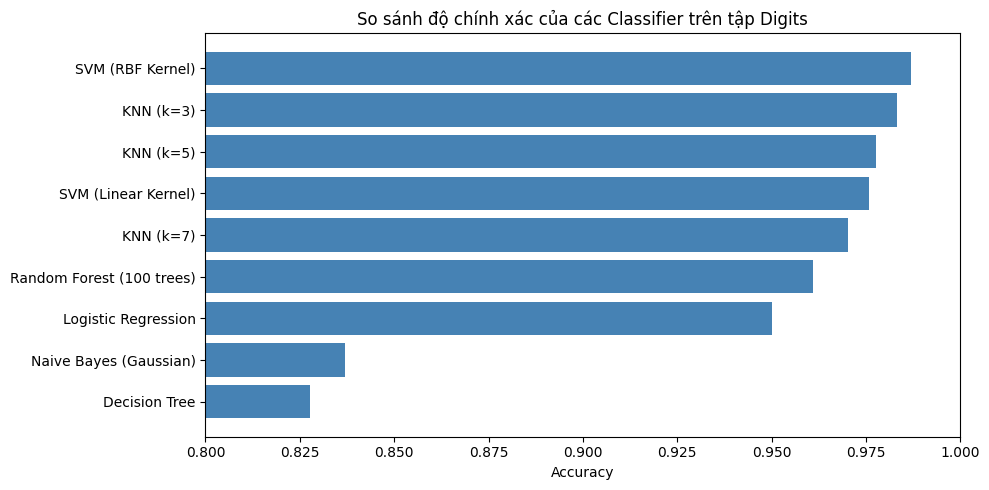

In [14]:
plt.figure(figsize=(10, 5))
bars = plt.barh(df_results["Classifier"], df_results["Accuracy"], color="steelblue")
plt.xlabel("Accuracy")
plt.title("So sánh độ chính xác của các Classifier trên tập Digits")
plt.xlim(0.8, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()